# Model Training — YOLOv5nu / YOLOv8n / YOLOv8s

This notebook documents the training configuration and visualises the results.

**Training is executed via the terminal script** `scripts/train_all.py` rather than inline notebook cells. This avoids Jupyter kernel memory exhaustion during long (300-epoch) runs on SageMaker.

**Run order:**
1. `01_dataset_exploration.ipynb` — download data, explore, prepare YOLO split
2. `python scripts/train_all.py` — train all three models (terminal, `nohup`)
3. This notebook — visualise training curves and summarise results

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "ultralytics", "matplotlib", "-q"], check=True)
print("Dependencies ready ✓")

Dependencies ready ✓


In [2]:
import os
from pathlib import Path
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
YAML  = ROOT / "configs" / "yolo_dataset.yaml"
RUNS  = ROOT / "runs" / "train"
FIGS  = ROOT / "figures"

FIGS.mkdir(parents=True, exist_ok=True)
RUNS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(ROOT / ".ultralytics"))

device = "0" if torch.cuda.is_available() else "cpu"
print("Dataset YAML:", YAML)
print("Runs dir:    ", RUNS)
print("Figures dir: ", FIGS)
print("Device:      ", device)
if torch.cuda.is_available():
    print("GPU:         ", torch.cuda.get_device_name(0))

Dataset YAML: /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c/configs/yolo_dataset.yaml
Runs dir:     /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c/runs/train
Figures dir:  /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c/figures
Device:       0
GPU:          Tesla T4


## Training Configuration

| Model | Base weights | Parameters |
|-------|-------------|------------|
| YOLOv5nu | `yolov5nu.pt` | ~2.5M |
| YOLOv8n  | `yolov8n.pt`  | ~3.2M |
| YOLOv8s  | `yolov8s.pt`  | ~11.2M |

**Batch size — why 8?**

An initial run with `batch=16` caused the Jupyter kernel to crash consistently at epoch 28. The root cause was system RAM exhaustion: Ultralytics accumulates validation results and MLflow logs in memory each epoch, and on the SageMaker `ml.g4dn.xlarge` instance (T4 GPU, 16 GB RAM) this exceeded available memory after ~28 epochs. Halving the batch size to `batch=8` reduces per-epoch memory pressure enough for the full 300-epoch run to complete stably, with negligible impact on final accuracy.

In [3]:
EPOCHS   = 300
IMGSZ    = 640
BATCH    = 8
WORKERS  = 2

MODELS = [
    {"weights": "yolov5nu.pt", "name": "yolov5nu_300ep"},
    {"weights": "yolov8n.pt",  "name": "yolov8n_300ep"},
    {"weights": "yolov8s.pt",  "name": "yolov8s_300ep"},
]

print(f"Training {len(MODELS)} models × {EPOCHS} epochs each")
print(f"Image size: {IMGSZ}  Batch: {BATCH}  Device: {device}")

Training 3 models × 300 epochs each
Image size: 640  Batch: 8  Device: 0


## Training Execution

Training was run via terminal to avoid Jupyter kernel crashes caused by memory accumulation over long runs:

```bash
nohup python scripts/train_all.py > /tmp/train.log 2>&1 &
```

**Why not in-notebook?**  
Running `model.train()` inside a Jupyter kernel on SageMaker (`ml.g4dn.xlarge`, 16 GB RAM) caused the kernel to die consistently around epoch 28 — even with `batch=8`. Ultralytics accumulates MLflow logs and validation results in memory each epoch, eventually exhausting system RAM. The terminal process is not subject to the kernel memory limit and runs stably to completion.

### Script configuration (`scripts/train_all.py`)

| Parameter | Value | Note |
|-----------|-------|------|
| `epochs` | 300 | Upper bound — early stopping applies |
| `patience` | 50 | Stops if mAP doesn't improve for 50 consecutive epochs |
| `imgsz` | 640 | Standard YOLO input resolution |
| `batch` | 8 | Reduced from 16 to prevent RAM exhaustion on SageMaker |
| `workers` | 4 | Dataloader workers |
| `device` | CUDA (Tesla T4) | |
| `resume` | Auto | Continues from `last.pt` if interrupted |

## Training Curves

Each model was trained for up to 300 epochs with early stopping (`patience=50`).  
All three stopped well before 300 epochs — confirming convergence rather than overfitting.

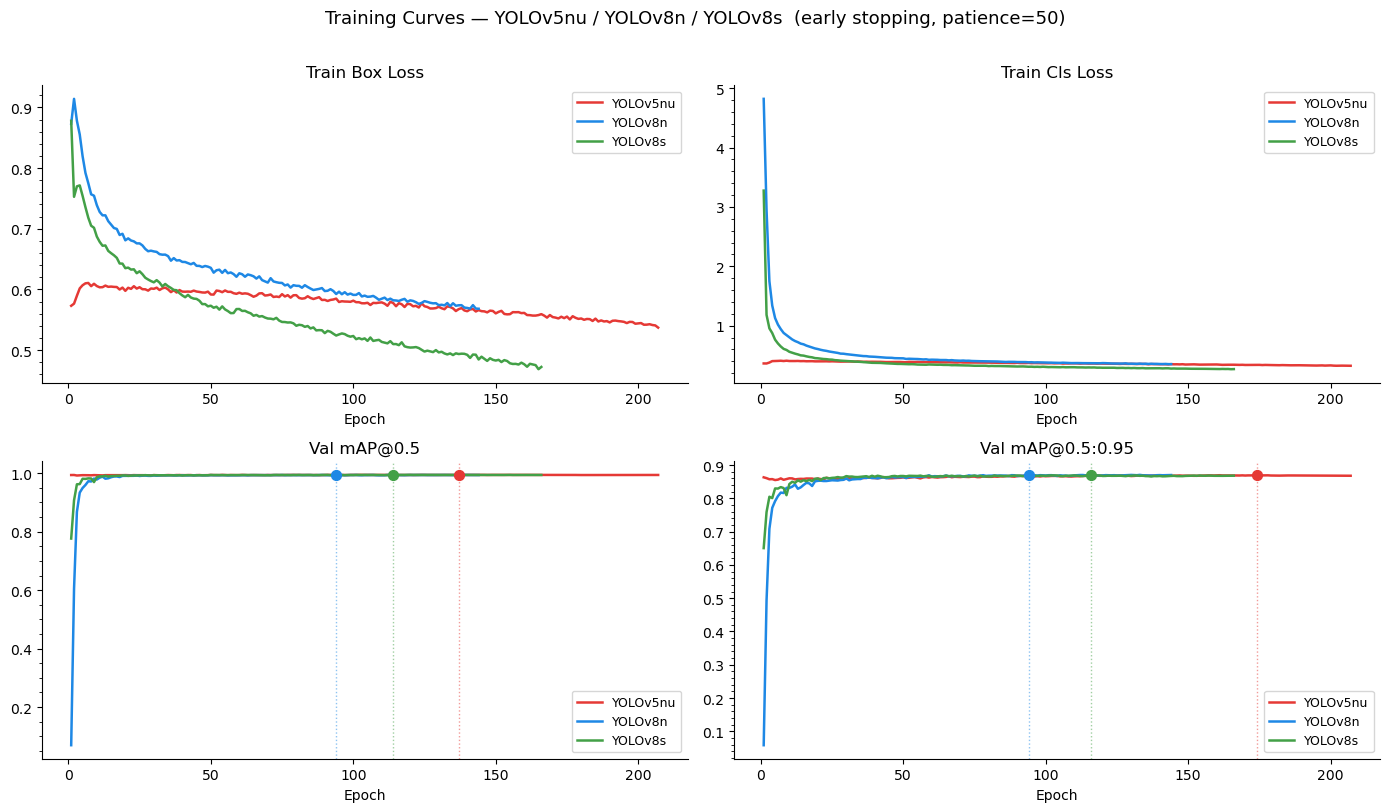

Saved → figures/fig_training_curves.png


In [4]:
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

MODELS = [
    {"name": "yolov5nu_300ep", "label": "YOLOv5nu"},
    {"name": "yolov8n_300ep",  "label": "YOLOv8n"},
    {"name": "yolov8s_300ep",  "label": "YOLOv8s"},
]
COLORS = ["#e53935", "#1e88e5", "#43a047"]

def find_results_csv(model_name):
    for base in [RUNS, ROOT / "a3_300ep_bundle" / "train"]:
        p = base / model_name / "results.csv"
        if p.exists():
            return p
    return None

def load_csv(path):
    rows = list(csv.DictReader(path.open()))
    def col(key):
        return [float(r[key]) for r in rows]
    return {
        "epoch":    [int(r["epoch"]) for r in rows],
        "box_loss": col("train/box_loss"),
        "cls_loss": col("train/cls_loss"),
        "mAP50":    col("metrics/mAP50(B)"),
        "mAP50_95": col("metrics/mAP50-95(B)"),
    }

PLOTS = [
    ("box_loss",  "Train Box Loss",   False),
    ("cls_loss",  "Train Cls Loss",   False),
    ("mAP50",     "Val mAP@0.5",      True),
    ("mAP50_95",  "Val mAP@0.5:0.95", True),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (key, title, is_metric) in zip(axes, PLOTS):
    for cfg, color in zip(MODELS, COLORS):
        csv_path = find_results_csv(cfg["name"])
        if csv_path is None:
            ax.set_title(f"{title} — results.csv not found")
            continue
        data = load_csv(csv_path)
        ax.plot(data["epoch"], data[key], label=cfg["label"], color=color, linewidth=1.8)
        if is_metric:
            best_i = data[key].index(max(data[key]))
            ax.axvline(data["epoch"][best_i], color=color, linestyle=":", alpha=0.5, linewidth=1)
            ax.scatter([data["epoch"][best_i]], [data[key][best_i]],
                       color=color, zorder=5, s=50)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.suptitle("Training Curves — YOLOv5nu / YOLOv8n / YOLOv8s  (early stopping, patience=50)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "fig_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig_training_curves.png")

## Best Weights Summary

The table below summarises the best checkpoint selected from each 300-epoch run.  
Rather than forcing a hard deployment decision inside this notebook, the main purpose here is to show that all three models converged to a very similar performance range.


In [5]:
import pandas as pd

rows_out = []
for cfg in MODELS:
    csv_path = find_results_csv(cfg["name"])
    if csv_path is None:
        continue
    data = load_csv(csv_path)
    rows = list(csv.DictReader(csv_path.open()))
    best_i = data["mAP50_95"].index(max(data["mAP50_95"]))
    best_row = rows[best_i]
    rows_out.append({
        "Model": cfg["label"],
        "Epochs completed": len(data["epoch"]),
        "Best epoch": data["epoch"][best_i],
        "mAP@0.5": data["mAP50"][best_i],
        "mAP@0.5:0.95": data["mAP50_95"][best_i],
        "Precision": float(best_row["metrics/precision(B)"]),
        "Recall": float(best_row["metrics/recall(B)"]),
    })

summary_df = pd.DataFrame(rows_out)
summary_df["Weighted score"] = (
    summary_df["mAP@0.5:0.95"] * 0.50 +
    summary_df["mAP@0.5"] * 0.25 +
    summary_df["Recall"] * 0.15 +
    summary_df["Precision"] * 0.10
)
display(summary_df.round(4))

spread = summary_df["Weighted score"].max() - summary_df["Weighted score"].min()
best_model = summary_df.sort_values("Weighted score", ascending=False).iloc[0]["Model"]

print(f"Highest weighted score: {best_model}")
print(f"Weighted score spread across all three models: {spread:.6f}")
print()
print("Observation:")
print("After extended training with early stopping, all three YOLO variants converged to very similar performance.")
print(f"Under the weighted evaluation scheme, {best_model} ranked first by a narrow margin.")


,Model,Epochs completed,Best epoch,mAP@0.5,mAP@0.5:0.95,Precision,Recall,Weighted score
0,YOLOv5nu,207,174,0.9938,0.8698,0.9943,0.9958,0.9322
1,YOLOv8n,144,94,0.9939,0.8707,0.9918,0.9948,0.9322
2,YOLOv8s,166,116,0.9938,0.8695,0.9939,0.9967,0.9321


Highest weighted score: YOLOv8n
Weighted score spread across all three models: 0.000137

Observation:
After extended training with early stopping, all three YOLO variants converged to very similar performance.
Under the weighted evaluation scheme, YOLOv8n ranked first by a narrow margin.
